THIS TRIAL WE ARE USING HAYDOCK LSTM MODEL. 5 YEARS. 80 TRAING 20 TESTING. ONLY DIFFERENCE IS THE IMPORTATION OF THE DATA IS NOT MANUAL ANYMORE AND SAME GOES FOR THE TEST AND TRAINING FILES.

In [58]:
### 1. Import Libraries and Fetch Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import yfinance as yf

# Fetching data using yfinance
stock_ticker = 'NVDA'  # Replace with your desired stock ticker
data = yf.Ticker(stock_ticker)
data = data.history(period="2y")
data.reset_index(inplace=True)

In [59]:
### 2. Data Cleaning
# Selecting relevant columns
data = data[['Date', 'Close']]
data.dropna(inplace=True)

In [60]:
### 3. Feature Engineering
# Adding Moving Averages, RSI, and Bollinger Bands
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data['RSI'] = 100 - (100 / (1 + data['Close'].diff().apply(lambda x: max(x, 0)).rolling(window=14).mean() /
                                 data['Close'].diff().apply(lambda x: abs(min(x, 0))).rolling(window=14).mean()))
data['BB_Mid'] = data['MA20']
data['BB_Upper'] = data['BB_Mid'] + 2 * data['Close'].rolling(window=20).std()
data['BB_Lower'] = data['BB_Mid'] - 2 * data['Close'].rolling(window=20).std()
data.dropna(inplace=True)


In [61]:
### 4. Splitting Data into Training and Testing Sets
# Splitting the data
train_size = int(len(data) * 0.8)  # 80% training, 20% testing
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Saving to CSV for inspection
train_data.to_csv("Training_Data.csv", index=False)
test_data.to_csv("Testing_Data.csv", index=False)

In [62]:
### 5. Scaling and Preparing Data for Model
# Fit the scaler only on training data
sc_train = MinMaxScaler(feature_range=(0, 1))
train_scaled = sc_train.fit_transform(train_data[['Close', 'MA20', 'MA50', 'RSI', 'BB_Mid', 'BB_Upper', 'BB_Lower']])
sc_test = MinMaxScaler(feature_range=(0, 1))
test_scaled = sc_test.fit_transform(test_data[['Close', 'MA20', 'MA50', 'RSI', 'BB_Mid', 'BB_Upper', 'BB_Lower']])

# Debugging scaling
print("Scaled Train Min:", np.min(train_scaled, axis=0))
print("Scaled Train Max:", np.max(train_scaled, axis=0))
print("Scaled Test Min:", np.min(test_scaled, axis=0))
print("Scaled Test Max:", np.max(test_scaled, axis=0))

# Preparing training data
X_train = []
y_train = []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i])
    y_train.append(train_scaled[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)

Scaled Train Min: [0. 0. 0. 0. 0. 0. 0.]
Scaled Train Max: [1. 1. 1. 1. 1. 1. 1.]
Scaled Test Min: [0. 0. 0. 0. 0. 0. 0.]
Scaled Test Max: [1. 1. 1. 1. 1. 1. 1.]


Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1429
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0229
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0109
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0106
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0076
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0086
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0083
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0073
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0061
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0060
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0055
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0054
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0067
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0047
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0051
E

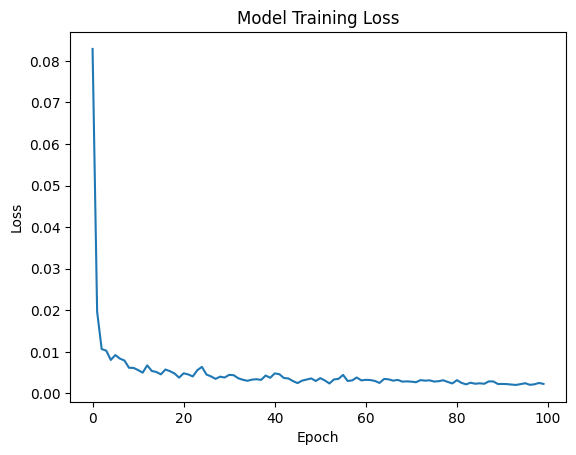

In [63]:
### 6. Building and Training the LSTM Model
from tensorflow.keras.layers import Bidirectional

# Building the LSTM model
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

# Compiling and fitting the model
regressor.compile(optimizer='adam', loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=100, batch_size=32)

# Plotting training loss
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


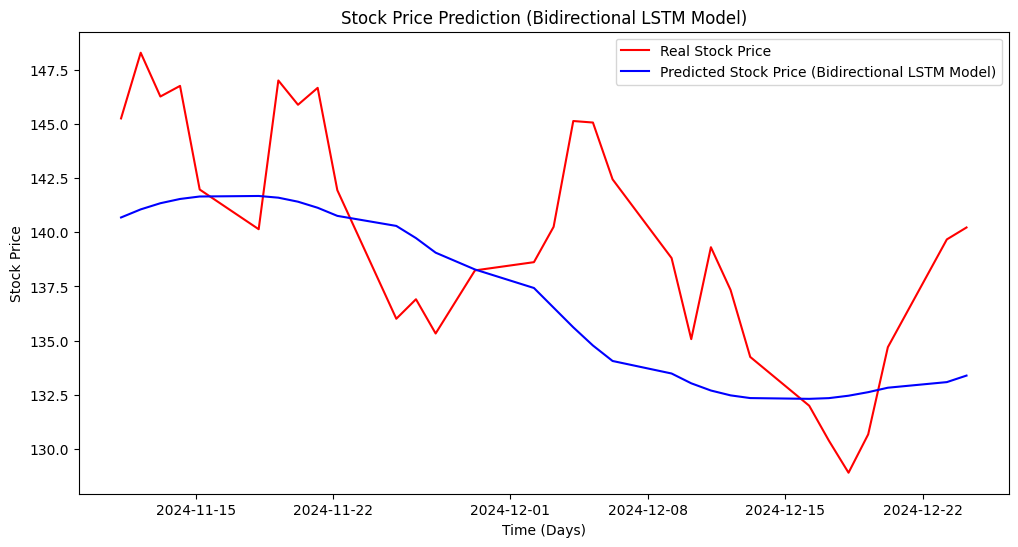

Trend Accuracy (LSTM Model): 56.67%
Mean Absolute Percentage Error (MAPE) (LSTM Model): 2.92%
Overall Accuracy Score (LSTM Model): 97.08%


In [66]:
### 7. Preparing Test Data and Making Predictions
# Preparing test data
X_test = []
y_test = test_data['Close'].values[60:]  # Actual 'Close' prices for comparison
for i in range(60, len(test_scaled)):
    X_test.append(test_scaled[i-60:i])
X_test = np.array(X_test, dtype=np.float32)

# Predicting stock prices
predicted_stock_price = regressor.predict(X_test, batch_size=32)
predicted_stock_price_expanded = np.zeros((predicted_stock_price.shape[0], test_scaled.shape[1]))
predicted_stock_price_expanded[:, 0] = predicted_stock_price.flatten()
predicted_stock_price = sc_test.inverse_transform(predicted_stock_price_expanded)[:, 0]

# Ensure all arrays have the same length
min_length = min(len(test_data['Date'].iloc[60:]), len(y_test), len(predicted_stock_price))
dates_aligned = test_data['Date'].iloc[60:].values[:min_length]
y_test_aligned = y_test[:min_length]
predicted_stock_price_aligned = predicted_stock_price[:min_length]

# Combine arrays and save fitted output
fitted_output = pd.DataFrame({
    'Date': dates_aligned,
    'Real Price': y_test_aligned,
    'Predicted Price': predicted_stock_price_aligned
})
fitted_output.to_csv("Fitted_Data_Output_LSTM_Model.csv", index=False)

# Plotting fitted data
plt.figure(figsize=(12, 6))
plt.plot(dates_aligned, y_test_aligned, color='red', label='Real Stock Price')
plt.plot(dates_aligned, predicted_stock_price_aligned, color='blue', label='Predicted Stock Price (Bidirectional LSTM Model)')
plt.title('Stock Price Prediction (Bidirectional LSTM Model)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

### Backtesting and Accuracy Assessment
# Calculating trend accuracy
trend_real = np.sign(np.diff(y_test_aligned))  # Actual trends (1 for up, -1 for down, 0 for no change)
trend_predicted = np.sign(np.diff(predicted_stock_price_aligned))  # Predicted trends
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

# Calculating Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_aligned - predicted_stock_price_aligned) / y_test_aligned)) * 100

# Overall accuracy score
overall_accuracy = 100 - mape

# Print metrics
print("Trend Accuracy (LSTM Model): {:.2f}%".format(trend_accuracy))
print("Mean Absolute Percentage Error (MAPE) (LSTM Model): {:.2f}%".format(mape))
print("Overall Accuracy Score (LSTM Model): {:.2f}%".format(overall_accuracy))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


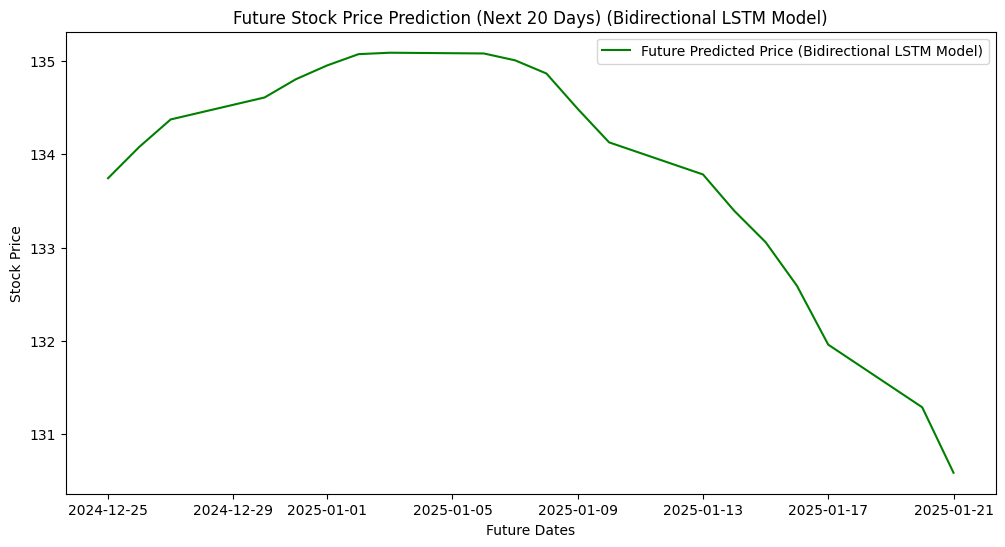

In [67]:
### 8. Future Prediction Logic (20 Days Ahead)
# Starting with the last 60 days of the test set
future_input = test_scaled[-60:, :]
future_predictions = []

for _ in range(20):
    # Reshape input to match the expected shape
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = regressor.predict(future_input)

    # Append the prediction to the results
    future_predictions.append(future_pred[0, 0])

    # Update the input by appending the prediction and removing the oldest step
    next_step = np.zeros((1, test_scaled.shape[1]))
    next_step[0, 0] = future_pred[0, 0]
    future_input = np.vstack([future_input[0, 1:, :], next_step])

# Rescale predictions back to original range
future_predictions = sc_test.inverse_transform(
    np.pad(np.array(future_predictions).reshape(-1, 1), ((0, 0), (0, test_scaled.shape[1] - 1)), constant_values=0)
)[:, 0]

# Generate future dates for predictions
future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]

# Save future predictions
future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions
})
future_output.to_csv("Future_Predictions_LSTM_Model.csv", index=False)

# Plotting future predictions
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, color='green', label='Future Predicted Price (Bidirectional LSTM Model)')
plt.title('Future Stock Price Prediction (Next 20 Days) (Bidirectional LSTM Model)')
plt.xlabel('Future Dates')
plt.ylabel('Stock Price')
plt.legend()
plt.show()